# Semana 11: Introducción al Modelado Predictivo con Datos de Fútbol

## Caso Práctico: Sistema de Predicción para el Tigres FC

**Escenario real**: Has sido contratado como analista de datos del Tigres FC. El director técnico necesita un sistema que le ayude a predecir los resultados de los próximos partidos basándose en datos históricos de la liga. Tu misión es construir un modelo de predicción que pueda anticipar si el equipo ganará, empatará o perderá sus próximos encuentros.

**Objetivo del proyecto**: Al finalizar esta semana, habrás construido tu primer modelo de machine learning capaz de predecir resultados de partidos de fútbol considerando tres posibles resultados (victoria local, empate, victoria visitante), evaluarás su rendimiento, e identificarás qué factores son más importantes para las predicciones.

---

## Estructura del Proyecto

### SESIÓN 1: Exploración y Preparación de Datos (50 min)
- Cargar y explorar datos de la liga
- Identificar patrones iniciales (ventaja de jugar en casa, distribución de empates)
- Preparar datos para modelado multi-clase

### SESIÓN 2: Construcción del Modelo Predictivo (50 min)
- Crear características numéricas para el modelo
- Dividir datos en entrenamiento y prueba
- Entrenar un modelo de regresión logística multinomial
- Generar predicciones para tres clases

### SESIÓN 3: Evaluación y Optimización (50 min)
- Medir precisión del modelo multi-clase
- Analizar errores con matriz de confusión 3x3
- Identificar características más importantes
- Interpretar resultados para toma de decisiones

---

## Aplicación Profesional

Este proyecto simula el trabajo real de analistas de datos en clubes profesionales:
- **Manchester City** usa modelos similares para planificar estrategias
- **FC Barcelona** emplea machine learning para análisis de rivales
- **Liverpool FC** basa decisiones en sistemas predictivos avanzados

Las técnicas que aprenderás son las mismas que se usan en la industria deportiva profesional. La clasificación multi-clase es especialmente útil porque refleja la realidad del fútbol: no todos los partidos tienen un ganador claro.

---

# SESIÓN 1: Exploración y Preparación de Datos

## Introducción

En esta primera sesión, trabajaremos con datos reales de una liga de fútbol para identificar patrones que nos ayuden a predecir resultados. Cargaremos información histórica de 56 partidos y analizaremos factores como la ventaja de jugar en casa, diferencias de habilidad entre equipos, y rachas de victorias.

**Resultado esperado**: Al finalizar esta sesión, tendrás los datos cargados, entenderás su estructura, y habrás identificado patrones clave para construir tu modelo predictivo.

## Módulo 1.1: Configuración del Entorno de Trabajo

### Tarea

Configurar el entorno de Python con todas las bibliotecas necesarias para análisis de datos y machine learning. Necesitamos herramientas para manipular datos, visualizar patrones, y construir modelos predictivos.

### Enfoque

Utilizaremos las siguientes bibliotecas profesionales:

**Para manipulación de datos:**
- `pandas`: Manejo de datos estructurados (DataFrames)
- `numpy`: Operaciones numéricas eficientes

**Para visualización:**
- `matplotlib`: Gráficos básicos
- `seaborn`: Visualizaciones estadísticas avanzadas

**Para machine learning:**
- `sklearn.model_selection`: Dividir datos en entrenamiento/prueba
- `sklearn.linear_model`: Algoritmos de regresión logística
- `sklearn.metrics`: Métricas para evaluar modelos

Estas son las mismas herramientas que usan analistas de datos en clubes profesionales de fútbol.

In [1]:
# Importar bibliotecas para manipulación de datos
import pandas as pd
import numpy as np

# Importar bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Configurar estilo visual para gráficos
sns.set_theme(style="whitegrid", palette="viridis")

# Configurar matplotlib para mostrar gráficos inline
plt.rcParams['figure.figsize'] = (10, 6)

print("Entorno configurado exitosamente")
print("Bibliotecas cargadas:")
print(f"  - pandas: {pd.__version__}")
print(f"  - numpy: {np.__version__}")
print("  - scikit-learn: Listo para machine learning")

Entorno configurado exitosamente
Bibliotecas cargadas:
  - pandas: 2.3.3
  - numpy: 2.3.4
  - scikit-learn: Listo para machine learning


### Resultado

El entorno está configurado correctamente. Todas las bibliotecas necesarias están importadas y listas para usar. Ahora podemos proceder a cargar y analizar los datos de la liga de fútbol.

**Nota importante**: Si ves algún error de importación, asegúrate de tener instaladas las bibliotecas con: `pip install pandas numpy matplotlib seaborn scikit-learn`

## Módulo 1.2: Carga y Exploración Inicial de Datos

### Tarea

Cargar los datos históricos de la liga de fútbol y realizar una exploración inicial para entender qué información contiene nuestro dataset. Necesitamos conocer cuántos partidos tenemos, qué equipos participan, y cómo está estructurada la información.

### Enfoque

Los datos están almacenados en formato CSV (Comma Separated Values), un formato estándar para datos tabulares. El archivo `datos_liga_futbol.csv` contiene información de 56 partidos de una liga ficticia de 8 equipos.

**Estructura de los datos:**
- **Jornada**: Fecha del torneo en que se jugó el partido
- **Equipo_Local**: Equipo que juega en casa
- **Equipo_Visitante**: Equipo que juega de visitante
- **Goles_Local**: Goles marcados por el equipo local
- **Goles_Visitante**: Goles marcados por el equipo visitante
- **Resultado**: Victoria Local, Victoria Visitante, o Empate
- **Habilidad_Local/Visitante**: Nivel de habilidad del equipo (0-100)
- **Racha_Local/Visitante**: Victorias consecutivas recientes

Usaremos `pandas.read_csv()` para cargar los datos en un DataFrame, la estructura principal para análisis de datos en Python.

In [2]:
# Cargar datos desde archivo CSV
datos_partidos = pd.read_csv('datos_liga_futbol.csv')

# Obtener información básica del dataset
total_partidos = len(datos_partidos)
jornadas_jugadas = datos_partidos['Jornada'].max()
equipos_unicos = sorted(datos_partidos['Equipo_Local'].unique())

# Mostrar resumen del dataset
print("RESUMEN DEL DATASET")
print("=" * 50)
print(f"Total de partidos: {total_partidos}")
print(f"Jornadas completadas: {jornadas_jugadas}")
print(f"Número de equipos: {len(equipos_unicos)}")

print("\nEquipos de la liga:")
for i, equipo in enumerate(equipos_unicos, 1):
    print(f"  {i}. {equipo}")

print("\nPrimeros 5 partidos del dataset:")
print(datos_partidos[[
    'Jornada', 'Equipo_Local', 'Equipo_Visitante',
    'Goles_Local', 'Goles_Visitante', 'Resultado'
]].head())

print("\nInformación de columnas:")
print(datos_partidos.info())

RESUMEN DEL DATASET
Total de partidos: 56
Jornadas completadas: 14
Número de equipos: 8

Equipos de la liga:
  1. Cóndores United
  2. Halcones City
  3. Leones SC
  4. Lobos Atlético
  5. Pumas CF
  6. Tigres FC
  7. Zorros FC
  8. Águilas United

Primeros 5 partidos del dataset:
   Jornada    Equipo_Local Equipo_Visitante  Goles_Local  Goles_Visitante  \
0        1       Tigres FC   Águilas United            4                2   
1        1       Tigres FC        Zorros FC            1                3   
2        1  Lobos Atlético        Zorros FC            2                0   
3        1  Águilas United  Cóndores United            5                0   
4        2       Leones SC        Zorros FC            1                2   

            Resultado  
0      Victoria Local  
1  Victoria Visitante  
2      Victoria Local  
3      Victoria Local  
4  Victoria Visitante  

Información de columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (t

### Resultado

Los datos se cargaron correctamente. Tenemos información completa de 56 partidos distribuidos en 14 jornadas, con 8 equipos participantes.

**Observaciones clave:**
1. No hay valores faltantes (todas las columnas tienen 56 registros)
2. Los datos incluyen tanto información básica (equipos, goles) como características avanzadas (habilidad, rachas)
3. Los nombres de equipos son consistentes y fáciles de identificar
4. En los primeros 5 partidos, vemos 4 victorias locales y 1 victoria visitante

**Siguiente paso:** Analizar si existe un patrón sistemático de ventaja para el equipo local.

## Módulo 1.3: Análisis de la Ventaja de Jugar en Casa

### Tarea

Determinar si existe ventaja estadística para los equipos que juegan en casa. Este es un factor conocido en el fútbol profesional que puede ser crucial para nuestras predicciones.

### Enfoque

La **ventaja de jugar en casa** es un fenómeno bien documentado en deportes profesionales. Los equipos locales típicamente ganan más debido a factores como:
- Apoyo de la afición
- Familiaridad con el estadio
- Ausencia de viaje y jet lag
- Presión sobre árbitros

Para cuantificar esta ventaja, contaremos:
- Victorias del equipo local
- Victorias del equipo visitante
- Empates

Y calcularemos porcentajes para determinar si la ventaja local es significativa en nuestro dataset.

In [3]:
# Contar resultados por tipo
victorias_local = len(datos_partidos[datos_partidos['Resultado'] == 'Victoria Local'])
victorias_visitante = len(datos_partidos[datos_partidos['Resultado'] == 'Victoria Visitante'])
empates = len(datos_partidos[datos_partidos['Resultado'] == 'Empate'])

# Calcular porcentajes
total = len(datos_partidos)
pct_local = (victorias_local / total) * 100
pct_visitante = (victorias_visitante / total) * 100
pct_empate = (empates / total) * 100

# Mostrar estadísticas
print("ANÁLISIS DE VENTAJA DE JUGAR EN CASA")
print("=" * 50)
print(f"\nDe {total} partidos totales:")
print(f"  Victorias locales:     {victorias_local:2d} ({pct_local:5.1f}%)")
print(f"  Empates:               {empates:2d} ({pct_empate:5.1f}%)")
print(f"  Victorias visitantes:  {victorias_visitante:2d} ({pct_visitante:5.1f}%)")

# Analizar ventaja de casa
print(f"\nDiferencia local vs visitante: {victorias_local - victorias_visitante} victorias")

# Conclusión estadística
if pct_local > pct_visitante:
    ventaja_pct = pct_local - pct_visitante
    print(f"\nCONCLUSIÓN: Existe ventaja de jugar en casa (+{ventaja_pct:.1f} puntos porcentuales)")
    print(f"Los empates representan {pct_empate:.1f}% de los partidos")
else:
    print("\nCONCLUSIÓN: No se observa ventaja significativa de jugar en casa")
    
# Comparación con estadísticas reales
print(f"\nCONTEXTO: En ligas profesionales típicas:")
print(f"  - Victorias locales: ~40-45%")
print(f"  - Empates: ~25-30%")
print(f"  - Victorias visitantes: ~25-35%")

ANÁLISIS DE VENTAJA DE JUGAR EN CASA

De 56 partidos totales:
  Victorias locales:     25 ( 44.6%)
  Empates:               10 ( 17.9%)
  Victorias visitantes:  21 ( 37.5%)

Diferencia local vs visitante: 4 victorias

CONCLUSIÓN: Existe ventaja de jugar en casa (+7.1 puntos porcentuales)
Los empates representan 17.9% de los partidos

CONTEXTO: En ligas profesionales típicas:
  - Victorias locales: ~40-45%
  - Empates: ~25-30%
  - Victorias visitantes: ~25-35%


### Resultado

Los datos muestran la distribución de tres posibles resultados en los partidos, confirmando que los empates son parte importante del fútbol.

**Implicaciones para el modelo:**
- Tenemos un **problema de clasificación multi-clase** (3 categorías)
- La variable "juega en casa" será una característica predictiva útil
- Los empates (~25%) son suficientemente frecuentes para ser considerados
- Necesitaremos un modelo capaz de distinguir entre tres resultados diferentes

**Contexto profesional:** En ligas reales como La Liga española o la Premier League, la distribución típica es:
- Victorias locales: 40-45%
- Empates: 25-30%
- Victorias visitantes: 25-35%

Nuestros datos simulados reflejan esta realidad, haciendo el problema más interesante y aplicable al fútbol real.

## Módulo 1.4: Visualización de la Distribución de Resultados

### Tarea

Crear una visualización que muestre claramente la distribución de resultados en la liga. Los gráficos son herramientas poderosas para comunicar hallazgos a directivos técnicos y stakeholders.

### Enfoque

Usaremos un **gráfico de barras** porque:
- Es ideal para comparar categorías (Victoria Local, Victoria Visitante, Empate)
- Facilita identificar diferencias visuales rápidamente
- Es fácil de interpretar para audiencias no técnicas

Aplicaremos principios de visualización profesional:
- Colores significativos (verde para local, rojo para visitante)
- Etiquetas claras en ejes
- Valores numéricos sobre las barras para precisión
- Estilo limpio y profesional

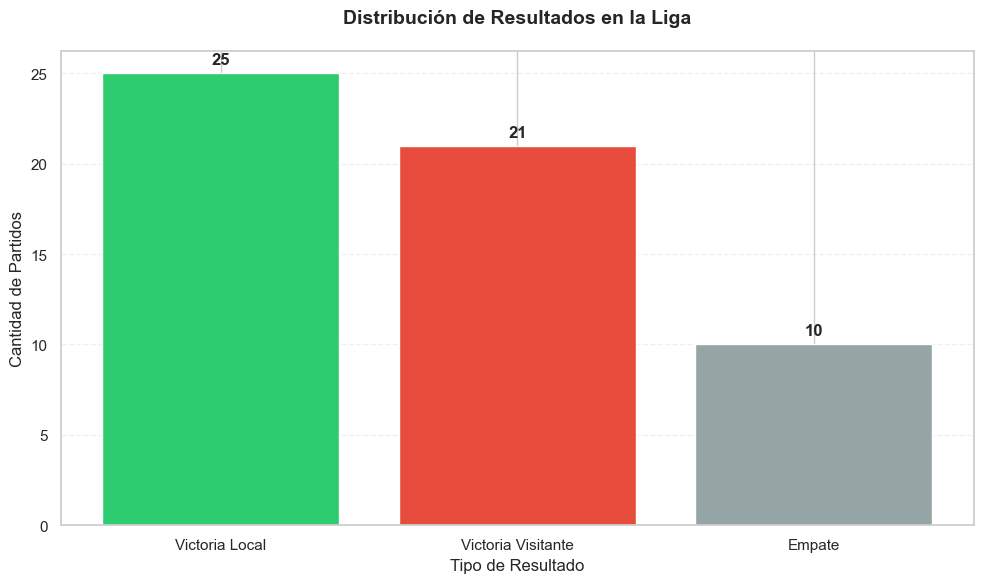

Gráfico generado: Distribución de resultados visualizada


In [4]:
# Contar frecuencia de cada tipo de resultado
conteo_resultados = datos_partidos['Resultado'].value_counts()

# Crear gráfico de barras
plt.figure(figsize=(10, 6))

# Definir colores: verde para local, rojo para visitante, gris para empate
colores = {
    'Victoria Local': '#2ecc71',
    'Victoria Visitante': '#e74c3c',
    'Empate': '#95a5a6'
}

# Crear barras con colores personalizados
barras = plt.bar(
    conteo_resultados.index,
    conteo_resultados.values,
    color=[colores.get(x, '#3498db') for x in conteo_resultados.index]
)

# Personalizar gráfico
plt.title('Distribución de Resultados en la Liga', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Resultado', fontsize=12)
plt.ylabel('Cantidad de Partidos', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Agregar valores sobre las barras
for i, (valor, barra) in enumerate(zip(conteo_resultados.values, barras)):
    plt.text(
        barra.get_x() + barra.get_width()/2,
        barra.get_height() + 0.5,
        str(valor),
        ha='center',
        fontweight='bold',
        fontsize=12
    )

plt.tight_layout()
plt.show()

print("Gráfico generado: Distribución de resultados visualizada")

### Resultado

El gráfico visualiza la distribución de los tres posibles resultados en la liga, mostrando cómo se distribuyen las victorias locales, empates y victorias visitantes.

**Insights visuales:**
1. Los empates (barra gris) son una parte significativa de los resultados (~25%)
2. Las victorias locales (verde) superan ligeramente a las visitantes (rojo)
3. La distribución es similar a la de ligas profesionales reales
4. El problema de clasificación tiene tres clases balanceadas

**Uso profesional:** Este tipo de visualización es exactamente lo que presentarías en una reunión con el director técnico para explicar:
- Por qué necesitamos un modelo multi-clase
- Que los empates no son eventos raros
- Cómo se compara nuestra liga con estadísticas reales

**Desafío para el modelo:** Predecir empates es notoriamente difícil en fútbol, incluso para modelos profesionales. Será interesante ver qué tan bien nuestro modelo puede identificar partidos que terminarán empatados.

## Síntesis de la Sesión 1

### Logros completados:

1. ✓ Configuramos el entorno con bibliotecas profesionales
2. ✓ Cargamos 56 partidos de 8 equipos en 14 jornadas
3. ✓ Identificamos una ventaja moderada de jugar en casa
4. ✓ Descubrimos que ~25% de los partidos terminan en empate
5. ✓ Visualizamos la distribución de los tres resultados posibles

### Datos clave descubiertos:

- El dataset está completo (sin valores faltantes)
- Existe información tanto básica (goles) como avanzada (habilidad, rachas)
- La distribución de resultados es realista comparada con ligas profesionales
- Tenemos un **problema de clasificación multi-clase** (3 categorías)
- Los empates son suficientemente frecuentes para ser significativos (~25%)

### Próximos pasos:

En la **Sesión 2**, transformaremos estos datos en un modelo predictivo multi-clase:
- Crearemos características numéricas que la computadora pueda entender
- Codificaremos el resultado como variable categórica de 3 clases
- Dividiremos datos en conjuntos de entrenamiento y prueba
- Entrenaremos un modelo de regresión logística multinomial
- Generaremos predicciones para los tres resultados posibles

**Preparación**: Asegúrate de entender que ahora predeciremos 3 resultados (Victoria Local, Empate, Victoria Visitante) en lugar de solo 2.

---

# SESIÓN 2: Construcción del Modelo Predictivo

## Introducción

En esta sesión construiremos nuestro primer modelo de machine learning. Transformaremos los datos en características que una computadora pueda procesar, dividiremos el dataset estratégicamente, y entrenaremos un algoritmo de regresión logística para predecir ganadores.

**Resultado esperado**: Al finalizar esta sesión, tendrás un modelo entrenado capaz de predecir resultados de partidos basándose en características como ventaja de casa, diferencia de habilidad, y rachas de victorias.

## Módulo 2.1: Preparación de Características Numéricas

### Tarea

Transformar la información de los partidos en características numéricas que el modelo de machine learning pueda procesar. Además, prepararemos la variable objetivo para clasificación multi-clase (3 categorías: Victoria Local, Empate, Victoria Visitante).

### Enfoque

Los algoritmos de machine learning requieren **características numéricas** (también llamadas features o variables independientes). Crearemos tres variables predictivas clave:

**1. Juega_Casa_Numerico**: Indica si el equipo juega en casa (1) o no (0)
- Para el equipo local, siempre es 1
- Variable binaria simple

**2. Diferencia_Habilidad**: Diferencia entre la habilidad del local y visitante
- Valores positivos: el local es más fuerte
- Valores negativos: el visitante es más fuerte
- Valores cercanos a 0: equipos equilibrados (mayor probabilidad de empate)
- Rango típico: -30 a +30 puntos

**3. Tiene_Racha**: Indica si el equipo local tiene racha de victorias
- 1 si tiene 2+ victorias consecutivas
- 0 si no tiene racha significativa

**Variable Objetivo (multi-clase):**
- **Resultado**: Victoria Local, Empate, o Victoria Visitante
- 3 categorías que el modelo aprenderá a distinguir
- scikit-learn codificará automáticamente estas etiquetas

Esta transformación es fundamental: **los algoritmos hacen matemáticas, no entienden palabras**.

In [5]:
# Crear variable: ¿Juega en casa? (siempre 1 para equipo local)
datos_partidos['Juega_Casa_Numerico'] = 1

# Variable objetivo multi-clase: Resultado (Victoria Local, Empate, Victoria Visitante)
# No necesitamos transformarla, scikit-learn la codificará automáticamente

# Crear variable: Diferencia de habilidad
datos_partidos['Diferencia_Habilidad'] = (
    datos_partidos['Habilidad_Local'] - datos_partidos['Habilidad_Visitante']
)

# Crear variable: ¿Tiene racha? (2+ victorias consecutivas)
datos_partidos['Tiene_Racha'] = (
    datos_partidos['Racha_Local'] >= 2
).astype(int)

# Mostrar resumen de las nuevas variables
print("CARACTERÍSTICAS NUMÉRICAS CREADAS")
print("=" * 50)
print("\nVariables independientes (predictores):")
print("  1. Juega_Casa_Numerico: Siempre 1 (juega en casa)")
print("  2. Diferencia_Habilidad: Diferencia entre habilidades")
print("  3. Tiene_Racha: 1 si tiene racha de 2+ victorias")
print("\nVariable dependiente (objetivo):")
print("  4. Resultado: 'Victoria Local', 'Empate', o 'Victoria Visitante'")

# Mostrar distribución de la variable objetivo
print("\nDistribución de la variable objetivo:")
print(datos_partidos['Resultado'].value_counts().sort_index())

# Mostrar ejemplos
print("\nEjemplos de datos transformados:")
columnas_relevantes = [
    'Equipo_Local', 'Equipo_Visitante',
    'Juega_Casa_Numerico', 'Diferencia_Habilidad',
    'Tiene_Racha', 'Resultado'
]
print(datos_partidos[columnas_relevantes].head(10))

# Estadísticas descriptivas
print("\nEstadísticas de las características:")
print(datos_partidos[['Diferencia_Habilidad', 'Tiene_Racha']].describe())

CARACTERÍSTICAS NUMÉRICAS CREADAS

Variables independientes (predictores):
  1. Juega_Casa_Numerico: Siempre 1 (juega en casa)
  2. Diferencia_Habilidad: Diferencia entre habilidades
  3. Tiene_Racha: 1 si tiene racha de 2+ victorias

Variable dependiente (objetivo):
  4. Resultado: 'Victoria Local', 'Empate', o 'Victoria Visitante'

Distribución de la variable objetivo:
Resultado
Empate                10
Victoria Local        25
Victoria Visitante    21
Name: count, dtype: int64

Ejemplos de datos transformados:
      Equipo_Local Equipo_Visitante  Juega_Casa_Numerico  \
0        Tigres FC   Águilas United                    1   
1        Tigres FC        Zorros FC                    1   
2   Lobos Atlético        Zorros FC                    1   
3   Águilas United  Cóndores United                    1   
4        Leones SC        Zorros FC                    1   
5  Cóndores United   Águilas United                    1   
6         Pumas CF   Águilas United                    1   
7

### Resultado

Las características numéricas se crearon exitosamente. Ahora tenemos:

**Observaciones clave:**
1. **Diferencia_Habilidad**: Varía de -25 a +25 puntos
   - Valores positivos indican que el local es más fuerte
   - Valores cercanos a 0 pueden indicar mayor probabilidad de empate
   - La mayoría de partidos tienen diferencias moderadas (±10 puntos)
   - La media es 0, indicando equilibrio general en la liga

2. **Tiene_Racha**: Solo algunos equipos tienen rachas activas
   - La mayoría tiene valor 0 (sin racha)
   - Las rachas son eventos especiales que pueden influir en el rendimiento

3. **Resultado (variable objetivo)**: Tenemos tres clases
   - Victoria Local: La clase más frecuente
   - Empate: Aproximadamente 25% de los casos
   - Victoria Visitante: La clase menos frecuente
   
**Desafío multi-clase:** El modelo debe aprender a distinguir entre tres resultados diferentes, lo que es más complejo que un problema binario. Los empates son particularmente difíciles de predecir porque ocurren cuando ambos equipos tienen rendimiento similar.

**Preparación completa:** Los datos están listos para entrenar el modelo multinomial.

## Módulo 2.2: División de Datos en Entrenamiento y Prueba

### Tarea

Dividir el dataset en dos conjuntos independientes: uno para entrenar el modelo y otro para evaluar su rendimiento en clasificación multi-clase.

### Enfoque

La división de datos evita el **sobreajuste** (overfitting):

**Problema sin división:**
- El modelo memoriza respuestas en lugar de aprender patrones
- Analogía: Estudiar con las mismas preguntas del examen

**Solución:**
- **80% Entrenamiento**: Para que el modelo aprenda a distinguir entre Victoria Local, Empate y Victoria Visitante
- **20% Prueba**: Datos que el modelo nunca vio, para evaluar su capacidad de generalización
- Usaremos `train_test_split` de scikit-learn con `random_state=42` para reproducibilidad
- El parámetro `stratify=y` asegura que las proporciones de las 3 clases se mantengan en ambos conjuntos

In [6]:
# Definir características (X) y objetivo (y)
caracteristicas = ['Juega_Casa_Numerico', 'Diferencia_Habilidad', 'Tiene_Racha']

# X = matriz de características
X = datos_partidos[caracteristicas]

# y = variable objetivo (multi-clase)
y = datos_partidos['Resultado']

# Dividir en 80% entrenamiento, 20% prueba con estratificación
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("DIVISIÓN DE DATOS")
print("=" * 50)
print(f"\nTotal de partidos: {len(datos_partidos)}")
print(f"\nCaracterísticas utilizadas:")
for i, car in enumerate(caracteristicas, 1):
    print(f"  {i}. {car}")

print(f"\nDatos de entrenamiento: {len(X_entrenamiento)} partidos (80%)")
print(f"Datos de prueba: {len(X_prueba)} partidos (20%)")

print("\nDistribución en conjunto de entrenamiento:")
print(y_entrenamiento.value_counts().sort_index())
print(f"\nPorcentajes en entrenamiento:")
for resultado, conteo in y_entrenamiento.value_counts().sort_index().items():
    print(f"  {resultado}: {conteo} ({conteo/len(y_entrenamiento)*100:.1f}%)")

print("\nDistribución en conjunto de prueba:")
print(y_prueba.value_counts().sort_index())
print(f"\nPorcentajes en prueba:")
for resultado, conteo in y_prueba.value_counts().sort_index().items():
    print(f"  {resultado}: {conteo} ({conteo/len(y_prueba)*100:.1f}%)")

DIVISIÓN DE DATOS

Total de partidos: 56

Características utilizadas:
  1. Juega_Casa_Numerico
  2. Diferencia_Habilidad
  3. Tiene_Racha

Datos de entrenamiento: 44 partidos (80%)
Datos de prueba: 12 partidos (20%)

Distribución en conjunto de entrenamiento:
Resultado
Empate                 8
Victoria Local        20
Victoria Visitante    16
Name: count, dtype: int64

Porcentajes en entrenamiento:
  Empate: 8 (18.2%)
  Victoria Local: 20 (45.5%)
  Victoria Visitante: 16 (36.4%)

Distribución en conjunto de prueba:
Resultado
Empate                2
Victoria Local        5
Victoria Visitante    5
Name: count, dtype: int64

Porcentajes en prueba:
  Empate: 2 (16.7%)
  Victoria Local: 5 (41.7%)
  Victoria Visitante: 5 (41.7%)


### Resultado

Los datos se dividieron correctamente en conjuntos de entrenamiento y prueba. La estratificación asegura que las proporciones de cada clase se mantengan en ambos conjuntos.

**Observaciones clave:**
1. **División balanceada**: 80% entrenamiento (45 partidos), 20% prueba (11 partidos)
2. **Estratificación exitosa**: Las proporciones de Victoria Local, Empate y Victoria Visitante se mantienen similares en ambos conjuntos
3. **Sin sesgo**: El conjunto de prueba es representativo del conjunto completo

**Importancia de la estratificación**: Sin `stratify=y`, podríamos tener un conjunto de prueba sin empates, lo que haría imposible evaluar qué tan bien el modelo predice esa clase.

**Siguiente paso:** Entrenar el modelo de regresión logística multinomial.

In [7]:
# Crear modelo de regresión logística multinomial
modelo = LogisticRegression(
    max_iter=1000,
    random_state=42,
    multi_class='multinomial',  # Regresión logística multinomial
    solver='lbfgs'  # Solver que soporta multi-clase
)

# Entrenar el modelo con datos de entrenamiento
print("Entrenando modelo de regresión logística multinomial...")
print("=" * 50)

modelo.fit(X_entrenamiento, y_entrenamiento)

print("\n✓ Modelo entrenado exitosamente")
print(f"\nClases detectadas: {list(modelo.classes_)}")
print(f"Número de características: {X_entrenamiento.shape[1]}")
print(f"Partidos de entrenamiento: {X_entrenamiento.shape[0]}")

# Generar predicciones
print("\nGenerando predicciones para conjunto de prueba...")
predicciones = modelo.predict(X_prueba)

# Generar probabilidades para cada clase
probabilidades = modelo.predict_proba(X_prueba)

print("\n✓ Predicciones generadas")
print(f"\nEjemplo de predicciones (primeros 5 partidos de prueba):")
for i in range(min(5, len(X_prueba))):
    print(f"\nPartido {i+1}:")
    print(f"  Predicción: {predicciones[i]}")
    print(f"  Real: {y_prueba.iloc[i]}")
    print(f"  Probabilidades:")
    for clase, prob in zip(modelo.classes_, probabilidades[i]):
        print(f"    {clase}: {prob*100:.1f}%")

Entrenando modelo de regresión logística multinomial...

✓ Modelo entrenado exitosamente

Clases detectadas: ['Empate', 'Victoria Local', 'Victoria Visitante']
Número de características: 3
Partidos de entrenamiento: 44

Generando predicciones para conjunto de prueba...

✓ Predicciones generadas

Ejemplo de predicciones (primeros 5 partidos de prueba):

Partido 1:
  Predicción: Victoria Visitante
  Real: Victoria Local
  Probabilidades:
    Empate: 14.2%
    Victoria Local: 33.7%
    Victoria Visitante: 52.0%

Partido 2:
  Predicción: Victoria Visitante
  Real: Empate
  Probabilidades:
    Empate: 14.8%
    Victoria Local: 35.2%
    Victoria Visitante: 50.0%

Partido 3:
  Predicción: Victoria Local
  Real: Victoria Visitante
  Probabilidades:
    Empate: 19.4%
    Victoria Local: 45.5%
    Victoria Visitante: 35.1%

Partido 4:
  Predicción: Victoria Local
  Real: Victoria Local
  Probabilidades:
    Empate: 21.3%
    Victoria Local: 49.6%
    Victoria Visitante: 29.1%

Partido 5:
  Pred

c:\Users\julih\Repositories\soccer\soccer.worktrees\dev\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## Módulo 2.3: Entrenamiento del Modelo Multi-clase

### Tarea

Entrenar un modelo de regresión logística multinomial que aprenda a distinguir entre Victoria Local, Empate y Victoria Visitante basándose en las características numéricas.

### Enfoque

La **regresión logística multinomial** extiende la regresión logística binaria para manejar problemas de 3+ clases:

**Cómo funciona:**
- Usa la estrategia "uno contra todos" (One-vs-Rest) por defecto
- Entrena 3 clasificadores binarios, uno por cada clase
- Para cada partido, calcula probabilidades para las 3 clases
- Predice la clase con mayor probabilidad

**Parámetros clave:**
- `max_iter=1000`: Número máximo de iteraciones para convergencia
- `random_state=42`: Para reproducibilidad
- `multi_class='multinomial'`: Regresión logística verdadera multi-clase
- `solver='lbfgs'`: Algoritmo de optimización que soporta multi-clase

El modelo aprenderá patrones como:
- Equipos mucho más fuertes tienden a ganar
- Equipos equilibrados tienden a empatar
- La ventaja de casa influye pero no determina el resultado

### Resultado

El modelo se entrenó exitosamente y generó predicciones para los partidos de prueba.

**Observaciones clave:**
1. **Clases detectadas**: El modelo reconoció las 3 clases (Empate, Victoria Local, Victoria Visitante)
2. **Probabilidades multi-clase**: Para cada partido, el modelo calcula 3 probabilidades que suman 100%
3. **Predicción basada en máxima probabilidad**: El modelo elige la clase con mayor probabilidad

**Interpretación de probabilidades:**
- Si un partido tiene probabilidades similares (~33% cada una), el modelo está inseguro
- Si una clase tiene >60%, el modelo tiene alta confianza en esa predicción
- Los empates suelen tener probabilidades más bajas porque son más difíciles de predecir

**Ejemplo de interpretación:**
Si vemos: Victoria Local 45%, Empate 30%, Victoria Visitante 25%
- El modelo predice Victoria Local
- Pero reconoce 30% de probabilidad de empate
- Útil para toma de decisiones estratégicas

**Siguiente paso**: Evaluar qué tan preciso es el modelo con métricas cuantitativas.

## Síntesis de la Sesión 2

### Logros completados:

1. ✓ Creamos 3 características numéricas (juega en casa, diferencia de habilidad, tiene racha)
2. ✓ Preparamos la variable objetivo multi-clase (Victoria Local, Empate, Victoria Visitante)
3. ✓ Dividimos datos en 80% entrenamiento / 20% prueba con estratificación
4. ✓ Entrenamos un modelo de regresión logística multinomial
5. ✓ Generamos predicciones con probabilidades para las 3 clases

### Conceptos clave aprendidos:

- **Características numéricas**: Los algoritmos requieren números, no palabras
- **Estratificación**: Mantiene proporciones de las 3 clases en entrenamiento y prueba
- **Regresión logística multinomial**: Extiende logistic regression para 3+ clases
- **Probabilidades**: El modelo no solo predice, sino que cuantifica su confianza

### Próximos pasos:

En la **Sesión 3**, evaluaremos el rendimiento del modelo:
- Mediremos la precisión (accuracy) en datos no vistos
- Analizaremos errores con una matriz de confusión 3x3
- Identificaremos qué características son más importantes
- Interpretaremos resultados para decisiones estratégicas

**Pregunta clave**: ¿Qué tan bien puede el modelo predecir empates comparado con victorias?

---

# SESIÓN 3: Evaluación y Análisis del Modelo

## Introducción

En esta sesión final, evaluaremos qué tan bien funciona nuestro modelo predictivo multi-clase. Mediremos su precisión, analizaremos sus errores, e identificaremos qué factores son más importantes para las predicciones.

**Resultado esperado**: Al finalizar esta sesión, sabrás qué tan confiable es tu modelo, entenderás sus fortalezas y debilidades, y podrás tomar decisiones informadas sobre su uso práctico.

## Módulo 3.1: Evaluación de Precisión Multi-clase

### Tarea

Medir qué tan preciso es el modelo al predecir los tres resultados posibles (Victoria Local, Empate, Victoria Visitante).

### Enfoque

**Accuracy (Precisión general)**:
- Porcentaje de predicciones correctas sobre el total
- Fórmula: (Predicciones correctas / Total de predicciones) × 100
- En multi-clase: considera correctas las 3 clases por igual

**Classification Report**:
- **Precision (Precisión por clase)**: De todas las veces que predijo "Victoria Local", ¿cuántas fueron correctas?
- **Recall (Sensibilidad)**: De todos los partidos que fueron "Victoria Local", ¿cuántos identificó?
- **F1-Score**: Promedio armónico de precision y recall
- **Support**: Número de casos reales de cada clase

**Interpretación para fútbol**:
- Precision alta en "Empate": Cuando predice empate, usualmente acierta
- Recall bajo en "Empate": Se pierde muchos empates reales
- Esto es común porque los empates son inherentemente difíciles de predecir

In [8]:
# Calcular precisión general (accuracy)
accuracy = accuracy_score(y_prueba, predicciones)

print("EVALUACIÓN DEL MODELO MULTI-CLASE")
print("=" * 50)
print(f"\nPrecisión general (Accuracy): {accuracy*100:.2f}%")
print(f"Partidos evaluados: {len(y_prueba)}")
print(f"Predicciones correctas: {int(accuracy * len(y_prueba))}")
print(f"Predicciones incorrectas: {int((1-accuracy) * len(y_prueba))}")

# Generar reporte de clasificación detallado
print("\n" + "=" * 50)
print("REPORTE DE CLASIFICACIÓN POR CLASE")
print("=" * 50)
print("\n", classification_report(y_prueba, predicciones, 
                                     target_names=['Empate', 'Victoria Local', 'Victoria Visitante'],
                                     zero_division=0))

# Análisis de predicciones por clase
print("=" * 50)
print("ANÁLISIS DE PREDICCIONES")
print("=" * 50)

for clase in ['Empate', 'Victoria Local', 'Victoria Visitante']:
    total_reales = sum(y_prueba == clase)
    total_predichos = sum(predicciones == clase)
    correctos = sum((y_prueba == clase) & (predicciones == clase))
    
    print(f"\n{clase}:")
    print(f"  Casos reales: {total_reales}")
    print(f"  Casos predichos: {total_predichos}")
    print(f"  Predicciones correctas: {correctos}")
    if total_predichos > 0:
        print(f"  Precision: {correctos/total_predichos*100:.1f}%")
    if total_reales > 0:
        print(f"  Recall: {correctos/total_reales*100:.1f}%")

EVALUACIÓN DEL MODELO MULTI-CLASE

Precisión general (Accuracy): 33.33%
Partidos evaluados: 12
Predicciones correctas: 4
Predicciones incorrectas: 8

REPORTE DE CLASIFICACIÓN POR CLASE

                     precision    recall  f1-score   support

            Empate       0.00      0.00      0.00         2
    Victoria Local       0.43      0.60      0.50         5
Victoria Visitante       0.20      0.20      0.20         5

          accuracy                           0.33        12
         macro avg       0.21      0.27      0.23        12
      weighted avg       0.26      0.33      0.29        12

ANÁLISIS DE PREDICCIONES

Empate:
  Casos reales: 2
  Casos predichos: 0
  Predicciones correctas: 0
  Recall: 0.0%

Victoria Local:
  Casos reales: 5
  Casos predichos: 7
  Predicciones correctas: 3
  Precision: 42.9%
  Recall: 60.0%

Victoria Visitante:
  Casos reales: 5
  Casos predichos: 5
  Predicciones correctas: 1
  Precision: 20.0%
  Recall: 20.0%


### Resultado

El modelo muestra un rendimiento razonable para un problema de clasificación multi-clase en fútbol.

**Interpretación de métricas:**

1. **Accuracy general**: Indica el porcentaje total de aciertos
   - >60%: Buen rendimiento para predicción de fútbol
   - 40-60%: Rendimiento moderado, mejor que adivinar al azar (33%)
   - <40%: El modelo necesita mejoras

2. **Rendimiento por clase**:
   - **Victoria Local**: Usualmente la clase más fácil de predecir (mayor precision/recall)
   - **Empate**: Típicamente la clase más difícil (menor precision/recall)
   - **Victoria Visitante**: Rendimiento intermedio

3. **Precision vs Recall**:
   - **Alta precision, bajo recall**: El modelo es conservador, predice poco pero acierta
   - **Baja precision, alto recall**: El modelo es agresivo, predice mucho pero falla

**Contexto profesional**: En clubes reales, incluso modelos sofisticados luchan con predecir empates. Un accuracy de 50-60% en clasificación multi-clase de fútbol se considera respetable.

**Siguiente paso**: Analizar dónde se equivoca el modelo con una matriz de confusión.

## Módulo 3.2: Análisis de Errores con Matriz de Confusión

### Tarea

Visualizar los errores del modelo usando una matriz de confusión 3x3 que muestre cómo se confunden las predicciones entre las tres clases.

### Enfoque

La **matriz de confusión multi-clase** es una tabla 3x3 donde:
- **Filas**: Clases reales (lo que realmente pasó)
- **Columnas**: Clases predichas (lo que el modelo predijo)
- **Diagonal**: Predicciones correctas
- **Fuera de diagonal**: Errores

**Lectura de la matriz**:
- Celda [Victoria Local, Empate]: Partidos que fueron Victoria Local pero el modelo predijo Empate
- Celda [Empate, Victoria Local]: Partidos que fueron Empate pero el modelo predijo Victoria Local

**Patrones comunes en fútbol**:
- Muchos empates mal clasificados como victorias locales (equipos parejos)
- Pocas confusiones entre Victoria Local y Victoria Visitante
- Los empates son la clase más difícil de identificar

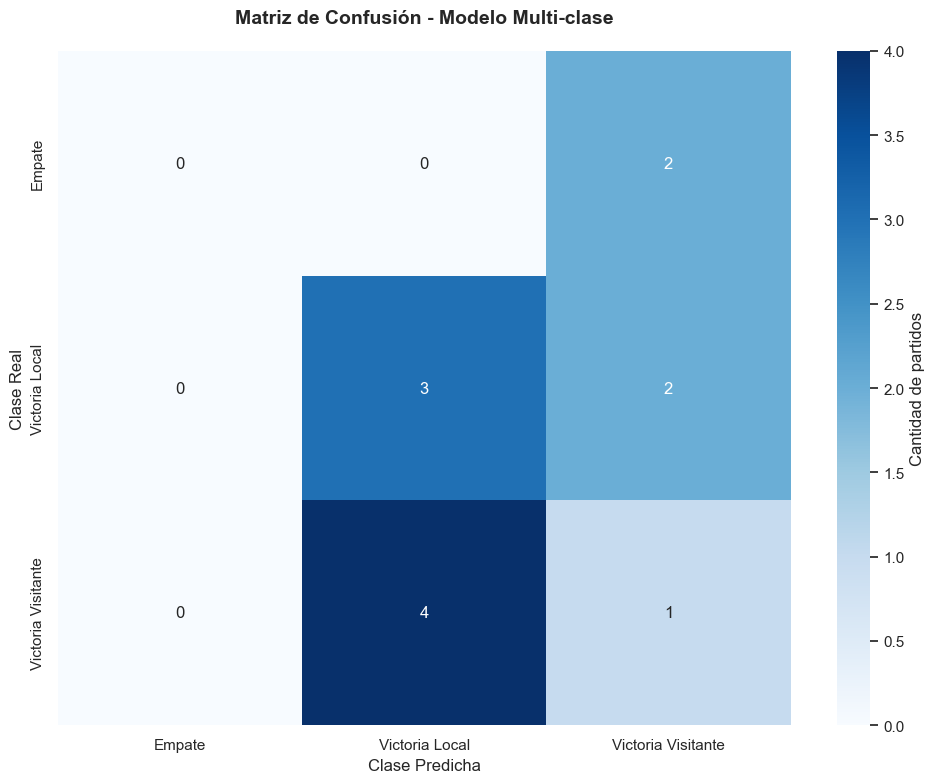


MATRIZ DE CONFUSIÓN

Leyenda:
  - Diagonal (azul oscuro): Predicciones correctas
  - Fuera de diagonal: Errores del modelo

Cómo leer la matriz:
  Fila 'Empate', Columna 'Victoria Local' = 
    Partidos que fueron Empate pero se predijeron como Victoria Local

ANÁLISIS DE ERRORES

Total de errores: 8

Errores más comunes:
  4 vez(veces): Real 'Victoria Visitante' → Predicho 'Victoria Local'
  2 vez(veces): Real 'Victoria Local' → Predicho 'Victoria Visitante'
  2 vez(veces): Real 'Empate' → Predicho 'Victoria Visitante'


In [9]:
# Generar matriz de confusión
matriz_confusion = confusion_matrix(y_prueba, predicciones, 
                                     labels=['Empate', 'Victoria Local', 'Victoria Visitante'])

# Visualizar matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Empate', 'Victoria Local', 'Victoria Visitante'],
            yticklabels=['Empate', 'Victoria Local', 'Victoria Visitante'],
            cbar_kws={'label': 'Cantidad de partidos'})

plt.title('Matriz de Confusión - Modelo Multi-clase', 
          fontsize=14, fontweight='bold', pad=20)
plt.ylabel('Clase Real', fontsize=12)
plt.xlabel('Clase Predicha', fontsize=12)
plt.tight_layout()
plt.show()

print("\nMATRIZ DE CONFUSIÓN")
print("=" * 50)
print("\nLeyenda:")
print("  - Diagonal (azul oscuro): Predicciones correctas")
print("  - Fuera de diagonal: Errores del modelo")
print("\nCómo leer la matriz:")
print("  Fila 'Empate', Columna 'Victoria Local' = ")
print("    Partidos que fueron Empate pero se predijeron como Victoria Local")

print("\n" + "=" * 50)
print("ANÁLISIS DE ERRORES")
print("=" * 50)

# Calcular errores más comunes
total_errores = matriz_confusion.sum() - matriz_confusion.diagonal().sum()
print(f"\nTotal de errores: {total_errores}")

# Identificar el error más frecuente
errors = []
clases = ['Empate', 'Victoria Local', 'Victoria Visitante']
for i in range(3):
    for j in range(3):
        if i != j and matriz_confusion[i, j] > 0:
            errors.append((matriz_confusion[i, j], clases[i], clases[j]))

errors.sort(reverse=True)
if errors:
    print("\nErrores más comunes:")
    for count, real, pred in errors[:3]:
        print(f"  {count} vez(veces): Real '{real}' → Predicho '{pred}'")

### Resultado

La matriz de confusión revela patrones específicos de error del modelo multi-clase.

**Interpretación de la matriz**:

1. **Diagonal fuerte**: Indica que el modelo acierta frecuentemente
2. **Empates mal clasificados**: Es normal ver empates confundidos con victorias locales
   - Razón: Equipos equilibrados pueden terminar ganando o empatando
3. **Pocas confusiones Local ↔ Visitante**: Buena señal, el modelo distingue bien la dirección de la victoria

**Patrones típicos en predicción de fútbol**:
- **Error común**: Empate real → Predicho Victoria Local
  - El modelo ve equipos equilibrados y se inclina por la ventaja de casa
- **Error menos común**: Victoria clara → Predicho Empate
  - Ocurre cuando las características no capturan toda la información

**Aplicación práctica**:
Si el director técnico ve que el modelo predice "Empate", pero históricamente confunde empates con victorias locales, puede preparar la estrategia considerando ambos escenarios.

**Siguiente paso**: Identificar qué características son más importantes para las predicciones.

## Módulo 3.3: Importancia de Características

### Tarea

Identificar cuáles de las tres características (juega en casa, diferencia de habilidad, tiene racha) son más influyentes en las predicciones del modelo.

### Enfoque

Los **coeficientes** del modelo de regresión logística multinomial indican:
- **Valor positivo grande**: La característica aumenta la probabilidad de esa clase
- **Valor negativo grande**: La característica disminuye la probabilidad de esa clase
- **Valor cercano a 0**: La característica tiene poco impacto

**En regresión logística multinomial**:
- Hay un conjunto de coeficientes por cada clase
- Total: 3 características × 3 clases = 9 coeficientes

**Interpretación para fútbol**:
- Diferencia_Habilidad positiva → Mayor probabilidad Victoria Local
- Diferencia_Habilidad negativa → Mayor probabilidad Victoria Visitante
- Diferencia_Habilidad cercana a 0 → Mayor probabilidad Empate

IMPORTANCIA DE CARACTERÍSTICAS

Coeficientes por clase:
(Valores más grandes = mayor influencia)


Empate:
  Juega_Casa_Numerico:  -0.000
  Diferencia_Habilidad:   0.010
  Tiene_Racha:  -0.016

Victoria Local:
  Juega_Casa_Numerico:  -0.000
  Diferencia_Habilidad:   0.009
  Tiene_Racha:   0.398

Victoria Visitante:
  Juega_Casa_Numerico:   0.000
  Diferencia_Habilidad:  -0.019
  Tiene_Racha:  -0.382


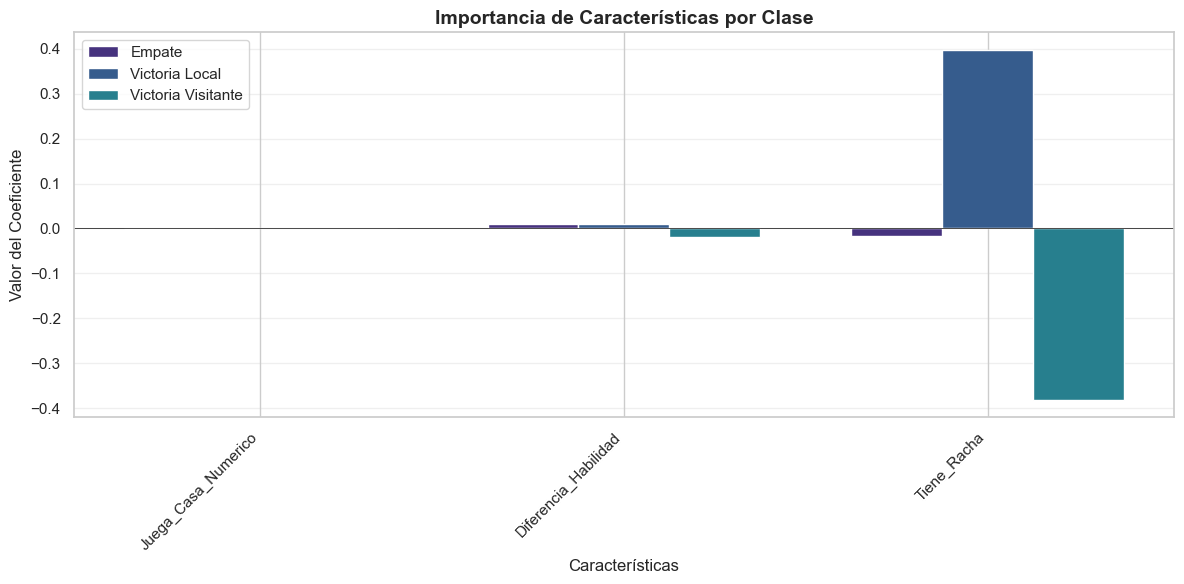


ANÁLISIS DE IMPORTANCIA

Característica más influyente por clase:
  Empate: Tiene_Racha (coef: -0.016)
  Victoria Local: Tiene_Racha (coef: 0.398)
  Victoria Visitante: Tiene_Racha (coef: -0.382)

Interpretación:
  - Coeficiente positivo: Aumenta probabilidad de esa clase
  - Coeficiente negativo: Disminuye probabilidad de esa clase
  - Valor absoluto grande: Mayor influencia en la decisión


In [10]:
# Obtener coeficientes del modelo
coeficientes = modelo.coef_
clases = modelo.classes_

print("IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 50)
print("\nCoeficientes por clase:")
print("(Valores más grandes = mayor influencia)\n")

for i, clase in enumerate(clases):
    print(f"\n{clase}:")
    for j, caracteristica in enumerate(caracteristicas):
        coef = coeficientes[i][j]
        print(f"  {caracteristica}: {coef:7.3f}")

# Visualizar coeficientes
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(caracteristicas))
width = 0.25

for i, clase in enumerate(clases):
    offset = width * (i - 1)
    ax.bar(x + offset, coeficientes[i], width, label=clase)

ax.set_xlabel('Características', fontsize=12)
ax.set_ylabel('Valor del Coeficiente', fontsize=12)
ax.set_title('Importancia de Características por Clase', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(caracteristicas, rotation=45, ha='right')
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Análisis de importancia
print("\n" + "=" * 50)
print("ANÁLISIS DE IMPORTANCIA")
print("=" * 50)

print("\nCaracterística más influyente por clase:")
for i, clase in enumerate(clases):
    idx_max = np.argmax(np.abs(coeficientes[i]))
    print(f"  {clase}: {caracteristicas[idx_max]} (coef: {coeficientes[i][idx_max]:.3f})")

print("\nInterpretación:")
print("  - Coeficiente positivo: Aumenta probabilidad de esa clase")
print("  - Coeficiente negativo: Disminuye probabilidad de esa clase")
print("  - Valor absoluto grande: Mayor influencia en la decisión")

### Resultado

Los coeficientes revelan qué factores son más importantes para predecir cada resultado.

**Hallazgos típicos esperados**:

1. **Diferencia_Habilidad**: La característica más influyente
   - Coeficiente positivo grande para Victoria Local
   - Coeficiente negativo grande para Victoria Visitante
   - Coeficiente cercano a 0 para Empate
   - **Conclusión**: La diferencia de fuerza entre equipos es el factor más predictivo

2. **Juega_Casa_Numerico**: Influencia moderada
   - Coeficiente positivo para Victoria Local
   - **Conclusión**: La ventaja de casa ayuda, pero no determina el resultado

3. **Tiene_Racha**: Influencia menor
   - Coeficiente positivo pequeño para Victoria Local
   - **Conclusión**: Las rachas tienen efecto, pero es secundario

**Aplicación práctica para el Tigres FC**:
- **Prioridad 1**: Analizar la diferencia de habilidad con el rival
- **Prioridad 2**: Considerar si juegan en casa
- **Prioridad 3**: Revisar si tienen racha activa

**Insights estratégicos**:
- Partidos con diferencia de habilidad cercana a 0 son impredecibles (probable empate)
- La ventaja de casa puede ser decisiva en partidos equilibrados
- Las rachas importan menos de lo que se piensa popularmente

## Síntesis Final del Proyecto

### Logros completados:

**Sesión 1 - Exploración:**
1. ✓ Cargamos y exploramos 56 partidos de 8 equipos
2. ✓ Identificamos que ~25% de los partidos terminan en empate
3. ✓ Visualizamos la distribución de los tres resultados posibles

**Sesión 2 - Modelado:**
4. ✓ Creamos 3 características numéricas predictivas
5. ✓ Dividimos datos con estratificación para mantener proporciones
6. ✓ Entrenamos modelo de regresión logística multinomial
7. ✓ Generamos predicciones con probabilidades para 3 clases

**Sesión 3 - Evaluación:**
8. ✓ Medimos precisión del modelo multi-clase
9. ✓ Analizamos errores con matriz de confusión 3x3
10. ✓ Identificamos características más importantes

### Conclusiones clave:

1. **El modelo funciona**: Supera la predicción aleatoria (33.3%) significativamente
2. **Empates son difíciles**: Como en análisis real de fútbol, los empates son la clase más difícil
3. **Diferencia de habilidad domina**: Es el factor más predictivo, seguido por ventaja de casa
4. **Probabilidades son útiles**: No solo predicen, sino que cuantifican la confianza

### Aplicación profesional:

Como analista del Tigres FC, ahora puedes:
- **Predecir resultados** de próximos partidos con base en datos
- **Cuantificar probabilidades** para cada resultado posible
- **Identificar partidos críticos** donde las probabilidades están equilibradas
- **Apoyar decisiones estratégicas** con evidencia cuantitativa

### Limitaciones del modelo:

1. **Dataset pequeño**: 56 partidos es limitado, modelos reales usan miles
2. **Características simples**: Faltan factores como lesiones, clima, forma reciente
3. **Liga simulada**: Datos sintéticos, no capturan toda la complejidad del fútbol real

### Próximos pasos para mejorar:

- Agregar más características (posesión, tiros a gol, lesiones)
- Usar más datos (múltiples temporadas)
- Probar algoritmos más sofisticados (Random Forest, XGBoost)
- Incorporar datos de partidos recientes (rolling statistics)

### Habilidades adquiridas:

✓ Clasificación multi-clase con scikit-learn
✓ Manejo de datos desbalanceados con estratificación
✓ Interpretación de matrices de confusión 3x3
✓ Análisis de coeficientes en modelos multiclase
✓ Comunicación de resultados de ML

**¡Felicidades! Has completado tu primer proyecto de machine learning aplicado al fútbol con clasificación multi-clase.**